Connected to lo_optim2 (Python 3.11.14)

Building JSA grid...

Running penalty-only optimization...

=== Outer 0 | λ = 1.00e-02 ===
Converged: True
Exit status code: 0
Constraint violation: 2.245e+01
Objective function value: 1.011194e+03

=== Outer 1 | λ = 2.00e-02 ===
Converged: True
Exit status code: 0
Constraint violation: 1.079e+01
Objective function value: 1.305263e+02

=== Outer 2 | λ = 4.00e-02 ===
Converged: True
Exit status code: 0
Constraint violation: 5.017e+00
Objective function value: 1.840675e+01

=== Outer 3 | λ = 8.00e-02 ===
Converged: True
Exit status code: 0
Constraint violation: 2.235e+00
Objective function value: 3.397694e+00

=== Outer 4 | λ = 1.60e-01 ===
Converged: True
Exit status code: 0
Constraint violation: 9.703e-01
Objective function value: 1.057913e+00

=== Outer 5 | λ = 3.20e-01 ===
Converged: True
Exit status code: 0
Constraint violation: 4.305e-01
Objective function value: 5.631594e-01

=== Outer 6 | λ = 6.40e-01 ===
Converged: True
Exit status code: 0
Constraint violation: 1.994e-01
Objecti

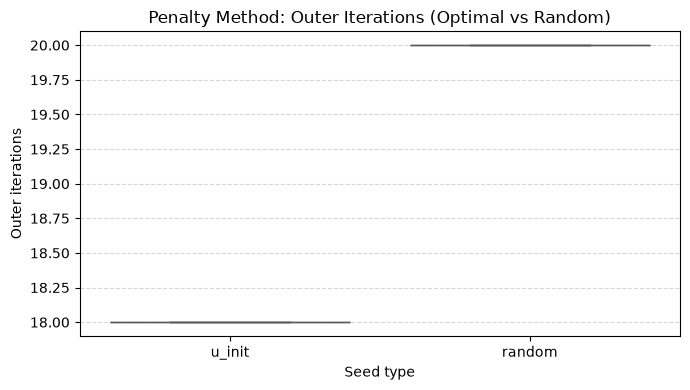

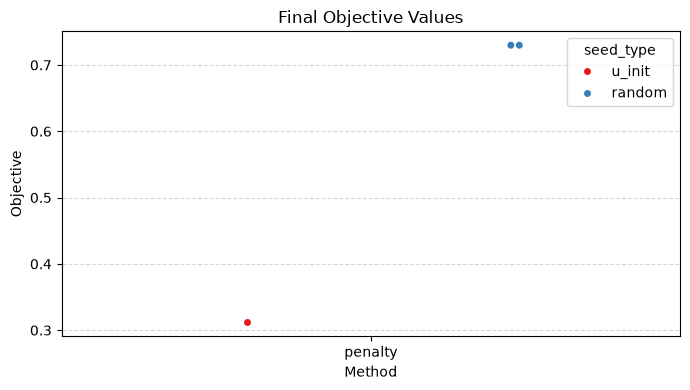

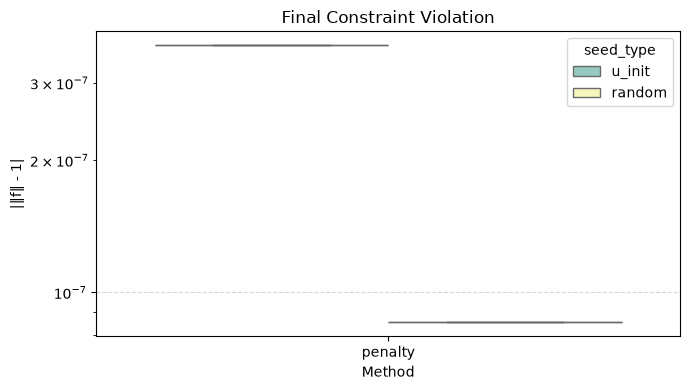

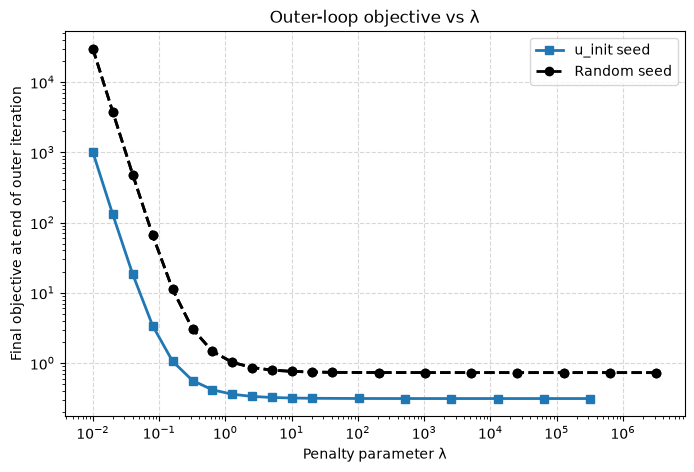


Plotting amplitudes...


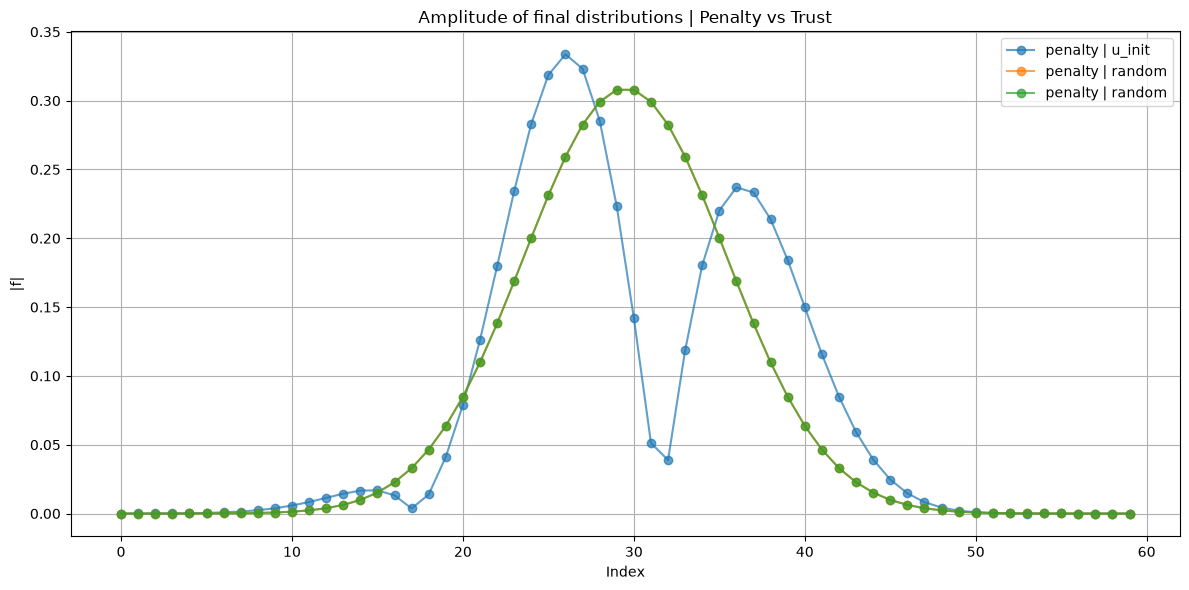

    method seed_type  seed_index  converged           final_fun  \
0  penalty    u_init         NaN       True  0.3120643063138972   
1  penalty    random         0.0       True  0.7298673566611668   
2  penalty    random         1.0       True   0.729867356661167   

   final_violation  final_lambda final_p  exit_code  
0     3.657002e-07      320000.0    None          0  
1     8.553132e-08     3200000.0    None          0  
2     8.553132e-08     3200000.0    None          0  

Experiment complete.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.ticker import MaxNLocator

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])

# Import your optimization and plotting utilities
from optimization_core import (
    build_jsa_grid,
    run_penalty_only,
    run_trust_only,
    save_results,
    load_results,
    plot_2d_projection,
    plot_modes,
    plot_init_mode,
    plot_all_amplitudes,
    plot_constraint_violation,
    plot_final_objective,
    plot_outer_iterations,
    plot_outer_objective_both_seeds,
    summarize_outer_results,
)

# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# Parameters for the multivariate normal distribution
n = 60  # Number of points in the frequency grid nxnxn
d = 3  # Dimensionality of the problem
mean = jnp.zeros(d)  # Mean
x_lim = 4  # Limits in x and y ax0is for plotting
rho_value = -0.46  # Correlation coefficient

filename = f"motivating_example_only_penalty_results_{d}D_r-0p46_weighted.pkl"

seed_init = 12345
K = 2  # Number of random seeds for optimization runs (for both methods)

bh_kwargs = {"n_iter": 500, "displ": True}

lambda0 = 1e-2
lambda_factor = 2
tol_constraint = 1e-6
max_outer_iters = 40
max_inner_iters = 500

params = {
    "n": n,
    "mean": mean,
    "x_lim": x_lim,
    "rho_value": rho_value,
    "seed_init": seed_init,
    "K": K,
    "bh_kwargs": bh_kwargs,
    "lambda0": lambda0,
    "lambda_factor": lambda_factor,
    "tol_constraint": tol_constraint,
    "max_outer_iters": max_outer_iters,
    "max_inner_iters": max_inner_iters,
}

# ---------------------------------------------------------
# 2. Build JSA grid and initial mode
# ---------------------------------------------------------

print("Building JSA grid...")
jsa = build_jsa_grid(n=n, mean=mean, rho=rho_value, x_lim=x_lim)

# Initial seed (optimal)
_, jsa_data = build_jsa_grid(n, mean, rho_value, x_lim)
# jsa_flat = jnp.reshape(jsa_data, (n, n ** (d - 1)))
# Reshaping the JSA explicitely to avoid issues with JAX's reshape function
jsa_flat = jsa_data.reshape((n,)*d)
jsa_flat = jsa_flat.reshape(n, -1)
u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

# plot_2d_projection(jsa_data)
# plot_modes(u,s,n_modes=8)

nv = 8
# u_init=u[:,:nv]@s[:nv]
u_init = jnp.sum(u[:, :nv], axis=1)
u_init_normal = u_init / jnp.linalg.norm(u_init)
f_init = jnp.concatenate([u_init_normal, jnp.zeros_like(u_init_normal)])
# plot_init_mode(u_init,u[:,0]/jnp.linalg.norm(u[:,0]))

# ---------------------------------------------------------
# 3. Generate reproducible random seeds
# ---------------------------------------------------------


def generate_seeds(K, seed_init):
    rng = np.random.default_rng(seed_init)
    return rng.integers(0, 2**32 - 1, size=K)


seeds = generate_seeds(K, seed_init)

# ---------------------------------------------------------
# 4. Run penalty-only (fast)
# ---------------------------------------------------------

print("\nRunning penalty-only optimization...")
df_pen = run_penalty_only(
    f_opt_init=f_init,
    jsa=jsa_data,
    seeds=seeds,
    lambda0=lambda0,
    lambda_factor=lambda_factor,
    tol_constraint=tol_constraint,
    max_outer_iters=max_outer_iters,
    max_inner_iters=max_inner_iters,
)


save_results(df_pen, params, seeds, filename=filename)
print("Penalty results saved.")

# ---------------------------------------------------------
# 5. Load results
# ---------------------------------------------------------

print("\nLoading saved results...")
df_pen_loaded, params_loaded, seeds_loaded = load_results(filename)

# ---------------------------------------------------------
# 7. Plots and data
# ---------------------------------------------------------
df = df_pen_loaded


def outer_converged(row):
    if row["outer_info"] is None:
        return None
    return row["outer_info"][-1]["converged"]


df["outer_converged"] = df.apply(outer_converged, axis=1)
print(df[df["method"] == "penalty"][["method", "seed_type", "outer_converged"]])

plot_outer_iterations(df)
plot_final_objective(df)
plot_constraint_violation(df)

plot_outer_objective_both_seeds(df)

# ---------------------------------------------------------
# 9. Plot amplitudes
# ---------------------------------------------------------

print("\nPlotting amplitudes...")
plot_all_amplitudes(df_pen_loaded)
# plot_all_amplitudes(df_trust_loaded)

summary = summarize_outer_results(df_pen_loaded)
print(summary)

print("\nExperiment complete.")

In [2]:
x = jnp.linspace(-x_lim, x_lim, n)

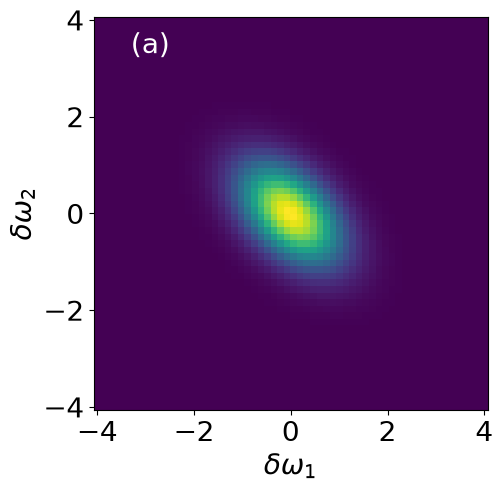

In [3]:
font = {"size": 20}
plt.rc("font", **font)

jsa_norm = jsa_data / jnp.linalg.norm(jsa_data)
jsa_proj = jnp.sum(jnp.square(jnp.abs(jsa_norm)), axis=0)

fig1, axs1 = plt.subplots(1, 1, sharex=True, sharey=True, constrained_layout=True)

c1 = axs1.pcolor(x, x, jsa_proj / np.max(jsa_proj), rasterized=True)

axs1.set_box_aspect(1)
axs1.set_xlabel(r"$\delta\omega_{1}$")
axs1.set_ylabel(r"$\delta\omega_{2}$")
# axs1.set_title('r=-0.46')
# fig1.colorbar(c1)

fig1.text(0.25, 0.9, "(a)", color="white")
plt.gca().set_aspect("equal")

# Automatically set ticks using MaxNLocator
axs1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))  # For x-axis
axs1.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))  # For y-axis

# Get current ticks
x_ticks = axs1.get_xticks()
y_ticks = axs1.get_yticks()

# Remove the first and last ticks
axs1.set_xticks(x_ticks[1:-1])
axs1.set_yticks(y_ticks[1:-1])

# plt.savefig('jsa_proj_r_n0p46.pdf', dpi=300, bbox_inches='tight')
plt.show()

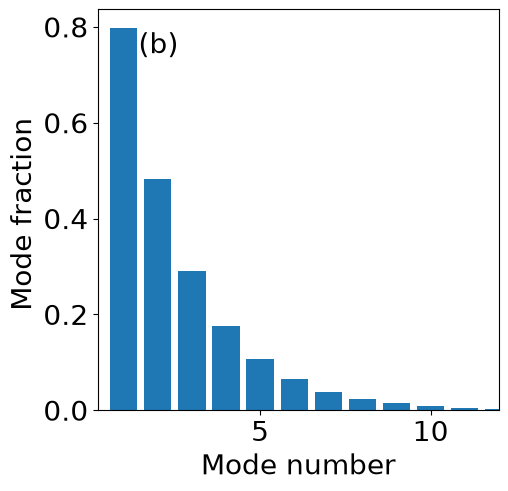

In [4]:
font = {"size": 20}
plt.rc("font", **font)

mode_number = np.arange(1, len(s))

fig2, axs2 = plt.subplots(1, 1, sharex=True, sharey=True, constrained_layout=True)

c2 = axs2.bar(mode_number, s[:-1] / jnp.linalg.norm(s[:-1]))

axs2.set_box_aspect(1)
axs2.set_xlabel(r"Mode number")
axs2.set_ylabel(r"Mode fraction ")
axs2.set_xlim(0.25, 12)
# axs2.set_ylim(0,1)
# fig1.colorbar(c1)

fig2.text(0.25, 0.9, "(b)", color="black")
# plt.gca().set_aspect('equal')

# # Automatically set ticks using MaxNLocator
# axs2.xaxis.set_major_locator(MaxNLocator(integer=True,nbins=6))  # For x-axis
# axs2.yaxis.set_major_locator(MaxNLocator(integer=True,nbins=6))  # For y-axis

# # Get current ticks
# x_ticks = axs2.get_xticks()
# y_ticks = axs2.get_yticks()

# # Remove the first and last ticks
# axs2.set_xticks(fontsize=20)
# axs2.set_yticks(fontsize=20)

plt.savefig("mode_distr_r_n0p46.pdf", dpi=300, bbox_inches="tight")
plt.show()

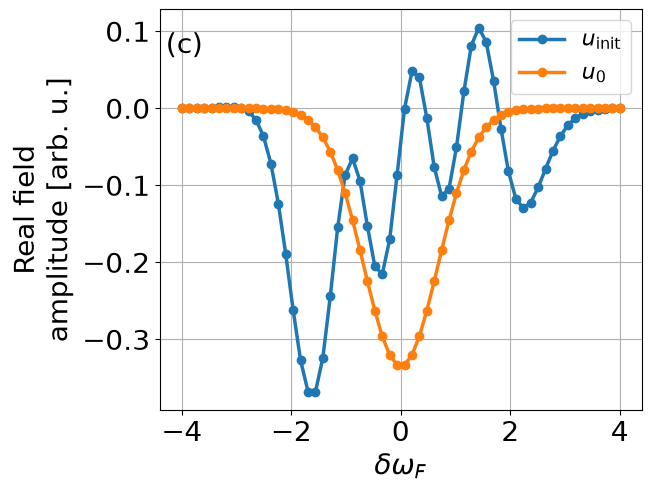

In [11]:
font = {"size": 20}
plt.rc("font", **font)
figv, axsv = plt.subplots(1, 1, sharex=True, sharey=True, constrained_layout=True)


plt.plot(x, u_init_normal, label=r"$u_{\text{init}}$", linewidth=2.5, marker="o")
plt.plot(
    x, u[:, 0] / jnp.linalg.norm(u[:, 0]), label=r"$u_0$", linewidth=2.5, marker="o"
)


plt.xlabel(r"$\delta\omega_{F}$")
plt.ylabel("Real field\namplitude [arb. u.]", ha="center")
plt.legend(fontsize=16)
plt.grid(True)

figv.text(0.25, 0.9, "(c)", color="black")
plt.savefig("initialization_r_n0p46.pdf", dpi=300, bbox_inches="tight")


plt.show()

#### Initialization with the first mode

In [6]:
filename2 = f"motivating_example_only_penalty_results_{d}D_r-0p46_2.pkl"
K2 = 1  # Number of random seeds
params2 = {
    "n": n,
    "mean": mean,
    "x_lim": x_lim,
    "rho_value": rho_value,
    "seed_init": seed_init,
    "K": K2,
    "bh_kwargs": bh_kwargs,
    "lambda0": lambda0,
    "lambda_factor": lambda_factor,
    "tol_constraint": tol_constraint,
    "max_outer_iters": max_outer_iters,
    "max_inner_iters": max_inner_iters,
}

u_init2 = u[:, 0] / jnp.linalg.norm(u[:, 0])
f_init2 = jnp.concatenate([u_init2, jnp.zeros_like(u_init2)])

seeds2 = generate_seeds(K2, seed_init)
print("\nRunning penalty-only optimization...")
df_pen2 = run_penalty_only(
    f_opt_init=f_init2,
    jsa=jsa_data,
    seeds=seeds2,
    lambda0=lambda0,
    lambda_factor=lambda_factor,
    tol_constraint=tol_constraint,
    max_outer_iters=max_outer_iters,
    max_inner_iters=max_inner_iters,
)


save_results(df_pen2, params2, seeds2, filename=filename2)


Running penalty-only optimization...

=== Outer 0 | λ = 1.00e-02 ===
Converged: True
Exit status code: 0
Constraint violation: 5.376e+01
Objective function value: 2.998943e+04

=== Outer 1 | λ = 2.00e-02 ===
Converged: True
Exit status code: 0
Constraint violation: 2.641e+01
Objective function value: 3.771171e+03

=== Outer 2 | λ = 4.00e-02 ===
Converged: True
Exit status code: 0
Constraint violation: 1.276e+01
Objective function value: 4.826705e+02

=== Outer 3 | λ = 8.00e-02 ===
Converged: True
Exit status code: 0
Constraint violation: 5.986e+00
Objective function value: 6.602612e+01

=== Outer 4 | λ = 1.60e-01 ===
Converged: True
Exit status code: 0
Constraint violation: 2.692e+00
Objective function value: 1.120448e+01

=== Outer 5 | λ = 3.20e-01 ===
Converged: True
Exit status code: 0
Constraint violation: 1.171e+00
Objective function value: 3.056117e+00

=== Outer 6 | λ = 6.40e-01 ===
Converged: True
Exit status code: 0
Constraint violation: 5.153e-01
Objective function value: 1.

In [7]:
print("\nLoading saved results...")
df_pen_loaded2, params_loaded2, seeds_loaded2 = load_results(filename2)

uin = df_pen_loaded.iloc[0]["f_opt"]
fin_re, fin_im = np.split(uin, 2)
fin_comp = fin_re + 1j * fin_im

u1 = df_pen_loaded2.iloc[0]["f_opt"]
f1_re, f1_im = np.split(u1, 2)
f1_comp = f1_re + 1j * f1_im

lamin = df_pen_loaded.iloc[0]["final_fun"]
lam1 = df_pen_loaded2.iloc[0]["final_fun"]


Loading saved results...


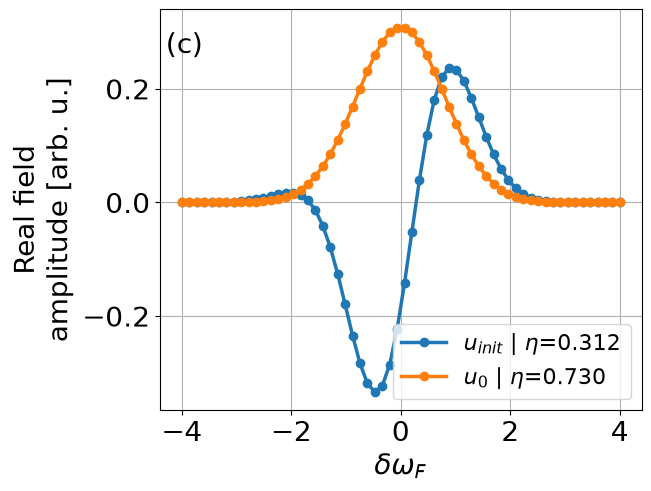

In [12]:
font = {"size": 20}
plt.rc("font", **font)
figv, axsv = plt.subplots(1, 1, sharex=True, sharey=True, constrained_layout=True)


plt.plot(
    x,
    fin_re / jnp.linalg.norm(fin_comp),
    label=r"$u_{init}$ | $\eta$=" + f"{lamin:.3f}",
    linewidth=2.5,
    marker="o",
)
plt.plot(
    x,
    f1_re / jnp.linalg.norm(f1_comp),
    label=r"$u_0$ | $\eta$=" + f"{lam1:.3f}",
    linewidth=2.5,
    marker="o",
)


plt.xlabel(r"$\delta\omega_{F}$")
plt.ylabel("Real field\namplitude [arb. u.]", ha="center")
plt.legend(fontsize=16)
plt.grid(True)

figv.text(0.25, 0.9, "(c)", color="black")
plt.savefig("optimal_lo_r_n0p46.pdf", dpi=300, bbox_inches="tight")


plt.show()